In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

In [2]:
# dataset
df = pd.read_csv('diabetes.csv')

df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,50,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,52,1
3,150,66,23,94,28.1,0.167,21,0
4,150,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 8)

In [4]:
df.columns

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# Exploratory Data Analysis

In [5]:
# descriptive staistics
df.describe()


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.117188,69.076823,20.536458,79.799479,31.992578,0.471876,33.243490,0.348958
std,31.805091,19.367794,15.952218,115.244002,7.884160,0.331329,11.758182,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,142.000000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# check null values
df.isnull().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# check duplicate values
df.duplicated().sum()

0

In [8]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

<Axes: >

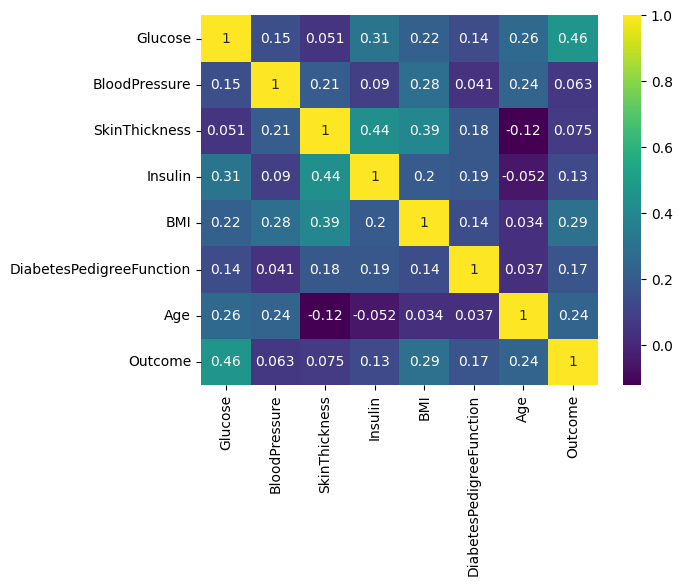

In [9]:
sns.heatmap(df.corr(),cmap='viridis',annot=True)

In [10]:
def feature_engineering(df):
    # handling 0
    col_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    
    for col in col_with_zeros:
        df[col] = df[col].replace(0,df[col].median())

    # bmi category to know underweight or overweight
    df['BMI_category'] = pd.cut(df['BMI'],bins=[0,18.5,25,30,100],labels=[1,2,3,4])

    # Insulin to glucose ration
    df['Insulin_to_glucose'] = df['Insulin'] / df['Glucose']

    # risk score
    df['Metabolic_risk'] = (df['Glucose'] * df['BMI']) / 100

    df['Log_Pedigree'] = np.log1p(df['DiabetesPedigreeFunction'])

    # age bin
    df['age_bin'] = pd.cut(df['Age'],bins=[0,30,50,100],labels=[1,2,3])

    return df

In [11]:
# apply the feature engineering
df_final = feature_engineering(df.copy())

In [12]:
# split the dataset
X = df_final.drop(['Outcome','Insulin_to_glucose','age_bin','Log_Pedigree'],axis=1)
y = df_final['Outcome']

In [13]:
# scaling the feature columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print('Feature Engineering and Scaling Complete')
X.head()


Feature Engineering and Scaling Complete


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_category,Metabolic_risk
0,148,50,35,30.5,33.6,0.627,50,4,49.728
1,85,66,29,30.5,26.6,0.351,31,3,22.610
2,183,64,23,30.5,23.3,0.672,52,2,42.639
3,150,66,23,94.0,28.1,0.167,21,3,42.150
4,150,40,35,168.0,43.1,2.288,33,4,64.650


In [14]:
# we'll split in 3-way training set, validation set,test set
import torch 
from torch.utils.data import TensorDataset,DataLoader
from sklearn.model_selection import train_test_split

# training set
X_train,X_temp,y_train,y_temp = train_test_split(X_scaled,y, test_size=0.3,random_state=42,stratify=y)

# validation set
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)

print("Splited the dataset in Training , Validation, Test set")

Splited the dataset in Training , Validation, Test set


In [15]:
# conver to pytorch tensors
train_dataset = TensorDataset(torch.FloatTensor(X_train),torch.LongTensor(y_train.values))
val_dataset = TensorDataset(torch.FloatTensor(X_val),torch.LongTensor(y_val.values))
test_dataset = TensorDataset(torch.FloatTensor(X_test),torch.LongTensor(y_test.values))

In [16]:
# Create dataloader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

print(f"Train Size: {len(train_dataset)}, Val Size: {len(val_dataset)}, Test Size: {len(test_dataset)}")

Train Size: 537, Val Size: 115, Test Size: 116


In [17]:
# Convert to float
X_train_t = torch.tensor(X_train,dtype=torch.float32)
y_train_t = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_val_t = torch.tensor(X_val,dtype=torch.float32)
y_val_t = torch.tensor(y_val.values,dtype=torch.float32).view(-1,1)

# Creating a DataLoader for Batching
train_loader = DataLoader(TensorDataset(X_train_t,y_train_t),batch_size=32,shuffle=True)

print('Converted Data into Tensors!')

Converted Data into Tensors!


In [18]:
import torch.nn as nn
import torch.optim as optim

# Define the architecture

class DiabetesPred(nn.Module):
    def __init__(self, input_dim):
        super(DiabetesPred,self).__init__()
        self.layer = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 3
            nn.Linear(32,16),
            nn.ReLU(),

            # Output
            nn.Linear(16,1),
        
        )
    def forward(self,x):
        return  self.layer(x)
    

In [19]:
input_dim = X_train.shape[1]
model = DiabetesPred(input_dim)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

Training on: cpu


In [21]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(device))
optimizer = optim.Adam(model.parameters(),lr=0.01)

In [22]:
# Model CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

Training on: cpu


In [23]:
# Early Stopping
class EarlyStopping:
    def __init__(self,patience=3,min_delta=0):
        self.patience= patience
        self.min_delta= min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter +=1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0
    
    def save_checkpoint(self,model):
        '''save model when validation loss decrease'''
        torch.save(model.state_dict(),'best_model.pt')

In [24]:
import time

epochs = 1000
model.to(device)

# Reduce learning rate if loss stop improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=8,factor=0.5)
early_stopper = EarlyStopping(patience=10)
optimizer = optim.Adam(model.parameters(),lr=0.005)
print(f"Starting Training on {device}")

for epoch in range(epochs):
    model.train()
    train_loss =0.0
    start_time = time.time()

    for i, (batch_x,batch_y) in enumerate(train_loader):
        batch_x,batch_y = batch_x.to(device),batch_y.to(device)

        # forward pass
        output = model(batch_x)
        loss = criterion(output,batch_y)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # print progress in every 100 batches
        if i % 100 ==0 and i>0:
            print(f" Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")
    # validation phase
    model.eval()
    val_loss= 0.0
    with torch.no_grad():
        X_val_t_dev, y_val_t_dev = X_val_t.to(device),y_val_t.to(device)
        val_outputs = model(X_val_t_dev)
        v_loss = criterion(val_outputs,y_val_t_dev)
        val_loss = v_loss.item()

    avg_train_loss = train_loss/ len(train_loader)

    # Update scheduler
    scheduler.step(val_loss)

    epoch_duration = time.time() - start_time
    print(f"==> Epoch [{epoch + 1}/{epochs}] Done!")
    print(f"    Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_duration:.1f}s")
    print("-"*50)
    early_stopper(val_loss,model)

    if early_stopper.early_stop:
        print("Early stopping triggered! Loading best model...")
        break

Starting Training on cpu
==> Epoch [1/1000] Done!
    Train Loss: 0.8542 | Val Loss: 0.8044 | Time: 0.0s
--------------------------------------------------
==> Epoch [2/1000] Done!
    Train Loss: 0.7385 | Val Loss: 0.7240 | Time: 0.0s
--------------------------------------------------
==> Epoch [3/1000] Done!
    Train Loss: 0.6909 | Val Loss: 0.6793 | Time: 0.0s
--------------------------------------------------
==> Epoch [4/1000] Done!
    Train Loss: 0.6709 | Val Loss: 0.6466 | Time: 0.0s
--------------------------------------------------
==> Epoch [5/1000] Done!
    Train Loss: 0.6414 | Val Loss: 0.6483 | Time: 0.0s
--------------------------------------------------
==> Epoch [6/1000] Done!
    Train Loss: 0.7001 | Val Loss: 0.6765 | Time: 0.0s
--------------------------------------------------
==> Epoch [7/1000] Done!
    Train Loss: 0.6324 | Val Loss: 0.6833 | Time: 0.0s
--------------------------------------------------
==> Epoch [8/1000] Done!
    Train Loss: 0.6549 | Val Loss

In [25]:
# Load the best weights from epoch 
model.load_state_dict(torch.load('best_model.pt'))
print('Best Model loaded and ready for prediction!')

Best Model loaded and ready for prediction!


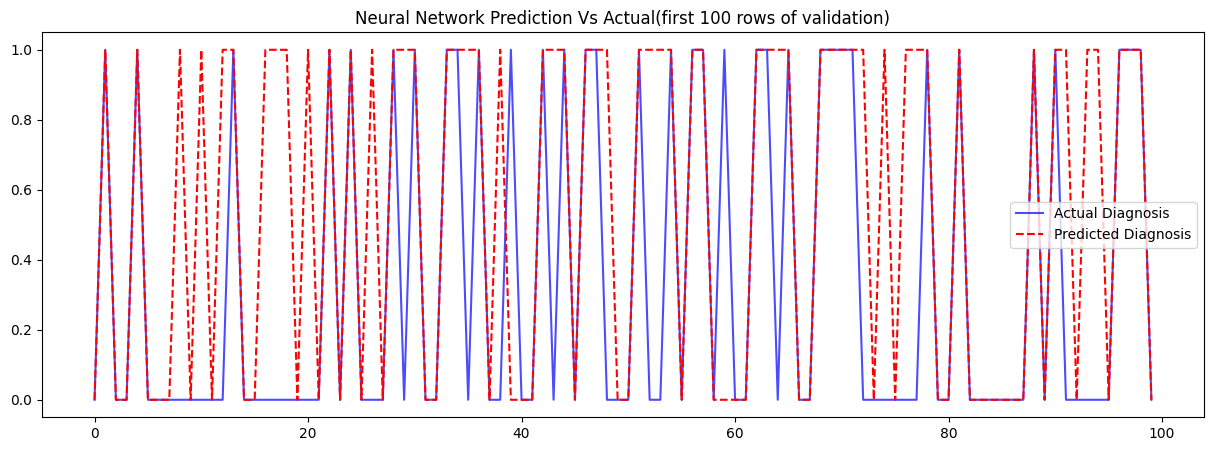

In [44]:
model.eval()
with torch.no_grad():
    logits = model(X_val_t_dev)
    # Apply Sigmoid manually to get 0-1 probabilities
    probs = torch.sigmoid(logits).cpu().numpy()
    
    # 0.5 is the standard threshold
    preds = (probs > 0.29 ).astype(int)
    actuals = y_val_t.cpu().numpy()
    
# Plot the first 100 points of the Validation set
plt.figure(figsize=(15,5))
plt.plot(actuals[:100],label='Actual Diagnosis', color='blue',alpha=0.7)
plt.plot(preds[:100],label='Predicted Diagnosis', color='red',linestyle='--')
plt.title('Neural Network Prediction Vs Actual(first 100 rows of validation)')
plt.legend()
plt.show()


In [45]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(actuals, preds))
print(classification_report(actuals, preds))

[[47 28]
 [ 2 38]]
              precision    recall  f1-score   support

         0.0       0.96      0.63      0.76        75
         1.0       0.58      0.95      0.72        40

    accuracy                           0.74       115
   macro avg       0.77      0.79      0.74       115
weighted avg       0.83      0.74      0.74       115



In [47]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(actuals, preds)
print(f"Accuracy: {acc * 100:.2f}%")

Accuracy: 73.91%
